# GP-UAE2 Golden Baseline (Clean Notebook)

This notebook is a clean, reproducible baseline for MNIST masked-image reconstruction using `GP_UAE2` in deterministic AE mode.


In [1]:
# Ensure local PyPOTS repo is imported (not stale site-packages)
import os
import sys

repo_root = os.path.abspath('..')
if repo_root in sys.path:
    sys.path.remove(repo_root)
sys.path.insert(0, repo_root)

for k in list(sys.modules.keys()):
    if k == 'pypots' or k.startswith('pypots.'):
        del sys.modules[k]

print('Repo root:', repo_root)


Repo root: /Users/vincente/Documents/Vie Pro/Phd/Code/Code_pour_manuscript/PyPOTS


In [2]:
# Imports
import os
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

from pypots.imputation import GP_UAE2
from pypots.optim.adam import Adam



████████╗██╗███╗   ███╗███████╗    ███████╗███████╗██████╗ ██╗███████╗███████╗    █████╗ ██╗
╚══██╔══╝██║████╗ ████║██╔════╝    ██╔════╝██╔════╝██╔══██╗██║██╔════╝██╔════╝   ██╔══██╗██║
   ██║   ██║██╔████╔██║█████╗█████╗███████╗█████╗  ██████╔╝██║█████╗  ███████╗   ███████║██║
   ██║   ██║██║╚██╔╝██║██╔══╝╚════╝╚════██║██╔══╝  ██╔══██╗██║██╔══╝  ╚════██║   ██╔══██║██║
   ██║   ██║██║ ╚═╝ ██║███████╗    ███████║███████╗██║  ██║██║███████╗███████║██╗██║  ██║██║
   ╚═╝   ╚═╝╚═╝     ╚═╝╚══════╝    ╚══════╝╚══════╝╚═╝  ╚═╝╚═╝╚══════╝╚══════╝╚═╝╚═╝  ╚═╝╚═╝
ai4ts v0.0.3 - building AI for unified time-series analysis, https://time-series.ai 



/Users/vincente/Documents/Vie Pro/Phd/Code/Code_pour_manuscript/PyPOTS/pypots/nn/modules/reformer/local_attention.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/Users/vincente/Documents/Vie Pro/Phd/Code/Code_pour_manuscript/PyPOTS/pypots/nn/modules/reformer/local_attention.py:98: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)


In [3]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print('Seed set to', SEED)


Seed set to 42


In [4]:
# Config (keep fixed for baseline)
img_size = 28
n_steps = 10
missing_prob = 0.15
n_train = 2000
n_val = 500

batch_size = 128
epochs = 20
latent_size = 32

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)


Device: cpu


In [5]:
# Load MNIST
transform = transforms.Compose([transforms.ToTensor()])
root = './data'

train_ds = datasets.MNIST(root=root, train=True, download=True, transform=transform)
val_ds = datasets.MNIST(root=root, train=False, download=True, transform=transform)

print('Train size:', len(train_ds))
print('Val size  :', len(val_ds))


Train size: 60000
Val size  : 10000


In [6]:
# Build masked inputs: x_in shape [N, 2, 28, 28] where channels are [masked_image, mask]
def build_masked_inputs(mnist_dataset, missing_prob=0.15):
    images = torch.stack([img for img, _ in mnist_dataset], dim=0)  # [N, 1, 28, 28]
    mask = (torch.rand_like(images) > missing_prob).float()         # [N, 1, 28, 28]
    masked_images = images * mask
    x_in = torch.cat([masked_images, mask], dim=1)                  # [N, 2, 28, 28]
    return x_in

x_train = build_masked_inputs(train_ds, missing_prob)
x_val = build_masked_inputs(val_ds, missing_prob)

print('x_train:', tuple(x_train.shape))
print('x_val  :', tuple(x_val.shape))


x_train: (60000, 2, 28, 28)
x_val  : (10000, 2, 28, 28)


In [7]:
# Convert to GP_UAE2 format: X and mask as [N, T, 28, 28]
x_train_ts = x_train[:n_train, 0].unsqueeze(1).repeat(1, n_steps, 1, 1).float()
m_train_ts = x_train[:n_train, 1].unsqueeze(1).repeat(1, n_steps, 1, 1).float()

x_val_ts = x_val[:n_val, 0].unsqueeze(1).repeat(1, n_steps, 1, 1).float()
m_val_ts = x_val[:n_val, 1].unsqueeze(1).repeat(1, n_steps, 1, 1).float()

train_set = {
    'X': x_train_ts,
    'mask': m_train_ts,
}

val_set = {
    'X': x_val_ts,
    'mask': m_val_ts,
    'X_ori': x_val_ts.clone(),
    'indicating_mask': torch.zeros_like(x_val_ts),
}

print('train X:', tuple(train_set['X'].shape), 'mask:', tuple(train_set['mask'].shape))
print('val   X:', tuple(val_set['X'].shape), 'mask:', tuple(val_set['mask'].shape))


train X: (2000, 10, 28, 28) mask: (2000, 10, 28, 28)
val   X: (500, 10, 28, 28) mask: (500, 10, 28, 28)


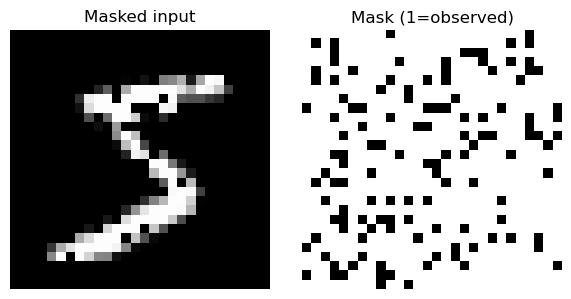

In [8]:
# Visual sanity check
i = 0
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(train_set['X'][i, 0].cpu(), cmap='gray')
ax[0].set_title('Masked input')
ax[1].imshow(train_set['mask'][i, 0].cpu(), cmap='gray')
ax[1].set_title('Mask (1=observed)')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()


In [9]:
# Output folder
run_tag = datetime.now().strftime('%Y%m%d_%H%M%S')
cwd = Path.cwd()
if (cwd / 'ipynbs').exists():
    out_dir = (cwd / 'ipynbs' / 'outputs' / f'golden_baseline_ae_{run_tag}').resolve()
else:
    out_dir = (cwd / 'outputs' / f'golden_baseline_ae_{run_tag}').resolve()
out_dir.mkdir(parents=True, exist_ok=True)

print('Output dir:', out_dir)


Output dir: /Users/vincente/Documents/Vie Pro/Phd/Code/Code_pour_manuscript/PyPOTS/ipynbs/outputs/golden_baseline_ae_20260309_134747


In [ ]:
# Train deterministic AE baseline
baseline_model = GP_UAE2(
    n_steps=n_steps,
    n_features=img_size * img_size,
    latent_size=latent_size,
    encoder_sizes=(64, 128),
    decoder_sizes=(128, 64),
    alpha=0.7,
    beta=0.0,
    p=0.05,
    deterministic_ae=True,
    recon_loss_type='bce_l1',
    recon_bce_weight=1.0,
    recon_l1_weight=0.5,
    train_gp=False,
    use_gp=False,
    optimizer=Adam(lr=1e-3, weight_decay=1e-5),
    batch_size=batch_size,
    epochs=epochs,
    patience=epochs,
    visualization_dir=str(out_dir),
    n_visual_samples=8,
    device=device,
    verbose=True,
)

baseline_model.fit(train_set=train_set, val_set=val_set)


2026-03-09 13:47:47 [INFO]: Using the given device: cpu
2026-03-09 13:47:47 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2026-03-09 13:47:47 [INFO]: GP_UAE2 initialized with the given hyperparameters, the number of trainable parameters: 3,859,329
2026-03-09 13:48:52 [INFO]: Epoch 001 - training loss: 0.6564, validation loss: 0.3928, train nll: 0.6564, train kl: 0.0000, val nll: 0.3928, val kl: 0.0000
2026-03-09 13:50:21 [INFO]: Epoch 002 - training loss: 0.3589, validation loss: 0.3402, train nll: 0.3589, train kl: 0.0000, val nll: 0.3402, val kl: 0.0000
2026-03-09 13:51:53 [INFO]: Epoch 003 - training loss: 0.3414, validation loss: 0.3280, train nll: 0.3414, train kl: 0.0000, val nll: 0.3280, val kl: 0.0000
2026-03-09 13:53:24 [INFO]: Epoch 004 - training loss: 0.3348, validation loss: 0.3258, train nll: 0.3348, train kl: 0.0000, val nll: 0.3258, val kl: 0.0000
2026-03-09 13:54:41 [INFO]: Epoch 005 - training loss: 0.3334, validation loss: 0

In [ ]:
baseline_model.p = 0.0  # Disable stochastic masking for first training
baseline_model.fit(train_set=train_set, val_set=val_set)


2026-03-07 18:18:55 [INFO]: Epoch 001 - training loss: 0.2760, validation loss: 0.2604, train nll: 0.2760, train kl: 0.0000, val nll: 0.2604, val kl: 0.0000
2026-03-07 18:20:03 [INFO]: Epoch 002 - training loss: 0.2527, validation loss: 0.2381, train nll: 0.2527, train kl: 0.0000, val nll: 0.2381, val kl: 0.0000
2026-03-07 18:21:13 [INFO]: Epoch 003 - training loss: 0.2303, validation loss: 0.2252, train nll: 0.2303, train kl: 0.0000, val nll: 0.2252, val kl: 0.0000
2026-03-07 18:22:20 [INFO]: Epoch 004 - training loss: 0.2180, validation loss: 0.2173, train nll: 0.2180, train kl: 0.0000, val nll: 0.2173, val kl: 0.0000
2026-03-07 18:23:30 [INFO]: Epoch 005 - training loss: 0.2078, validation loss: 0.2101, train nll: 0.2078, train kl: 0.0000, val nll: 0.2101, val kl: 0.0000
2026-03-07 18:24:40 [INFO]: Epoch 006 - training loss: 0.1981, validation loss: 0.1995, train nll: 0.1981, train kl: 0.0000, val nll: 0.1995, val kl: 0.0000
2026-03-07 18:25:52 [INFO]: Epoch 007 - training loss: 0.1

In [ ]:
# Save baseline weights for transfer learning experiments
weights_path = out_dir / 'baseline_ae_weights.pth'
baseline_model.save_weights(str(weights_path))
print('Saved weights:', weights_path)


2026-03-08 12:30:28 [INFO]: Saved GP_UAE2 weights to /Users/vincente/Documents/Vie Pro/Phd/Code/Code_pour_manuscript/PyPOTS/ipynbs/outputs/golden_baseline_ae_20260307_180438/baseline_ae_weights.pth


Saved weights: /Users/vincente/Documents/Vie Pro/Phd/Code/Code_pour_manuscript/PyPOTS/ipynbs/outputs/golden_baseline_ae_20260307_180438/baseline_ae_weights.pth


In [ ]:
# Quick reconstruction check
n_eval = 8
batch = {'X': val_set['X'][:n_eval], 'mask': val_set['mask'][:n_eval]}
pred = baseline_model.predict(batch, with_gp=False)
x_hat = torch.from_numpy(pred['imputation']).float()

idx, t = 0, 0
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
ax[0].imshow(val_set['X'][idx, t].cpu(), cmap='gray')
ax[0].set_title('Input (masked)')
ax[1].imshow(x_hat[idx, t].cpu(), cmap='gray')
ax[1].set_title('Reconstruction')
ax[2].imshow(val_set['mask'][idx, t].cpu(), cmap='gray')
ax[2].set_title('Mask')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# Inspect saved artifacts
print('Files in output dir:')
for p in sorted(out_dir.iterdir()):
    print(' -', p.name)

epoch_img_dir = out_dir / 'epoch_images'
if epoch_img_dir.exists():
    imgs = sorted(epoch_img_dir.glob('epoch_*.png'))
    print('Epoch images:', len(imgs))
    if len(imgs):
        print('First:', imgs[0])
        print('Last :', imgs[-1])


## Optional: Transfer Learning Bootstrap (from AE)

Run this only after the baseline cell above has completed.


In [ ]:
# Optional: initialize a non-deterministic model from baseline AE backbone
vae_tl = GP_UAE2(
    n_steps=n_steps,
    n_features=img_size * img_size,
    latent_size=latent_size,
    encoder_sizes=(64, 128),
    decoder_sizes=(128, 64),
    alpha=0.8,
    beta=1e-2,
    p=0.15,
    deterministic_ae=False,
    recon_loss_type='mse',
    train_gp=False,
    use_gp=False,
    pretrained_weights_path=str(weights_path),
    load_backbone_only=True,
    freeze_loaded_backbone=False,
    optimizer=Adam(lr=5e-4, weight_decay=1e-5),
    batch_size=batch_size,
    epochs=10,
    patience=10,
    visualization_dir=str(out_dir / 'vae_tl_from_ae'),
    n_visual_samples=8,
    device=device,
    verbose=True,
)

# Uncomment to train TL model:
# vae_tl.fit(train_set=train_set, val_set=val_set)
print('Transfer-learning model ready. Uncomment fit() to run.')
